# Inventory Stockout Prediction — EDA + Preprocessing Notebook

For this project I used this notebook to break down the dataset step-by-step so that I understand what occurs  before training the machine learning model.

**My Main Project goal:** predict whether a salon inventory item is at risk of a stockout.

**Target variable:**
In this model my target variable is **stockout** which takes places whne an inventory item is used completely 

# Importing Needed Libraries

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)



# Loading The Dataset
I used the copied file path to get the correct data to the model. I also printed the first few rows to gain an understanding of whta my full dataset lookes like. 

In [2]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\sadak\OneDrive\Desktop\CapstoneProject-\data\inventory_final_capstone.csv")
df.head()


,date,item_name,style_type,price,stock_level,quantity_sold,promotion,is_weekend,is_holiday,appointments_per_day,day_of_week,month,item_style,lag_sales,rolling_avg_3,units_per_appt,stock_pressure
0,2024-01-01,premium_braiding_hair,cornrows,17.77,35,35,1,0,1,8,0,1,premium_braiding_hair_cornrows,24.270841,24.270841,3.888889,3.888889
1,2024-01-01,standard_braiding_hair,cornrows,14.59,17,17,0,0,1,9,0,1,standard_braiding_hair_cornrows,24.270841,24.270841,1.700000,1.700000
2,2024-01-01,beads,knotless,4.54,16,16,1,0,1,10,0,1,beads_knotless,24.270841,24.270841,1.454545,1.454545
3,2024-01-01,edge_control,twists,7.60,74,11,0,0,1,8,0,1,edge_control_twists,24.270841,24.270841,1.222222,8.222222
4,2024-01-01,hair_gel,twists,5.98,69,18,0,0,1,9,0,1,hair_gel_twists,24.270841,24.270841,1.800000,6.900000


In [3]:
print(df)

            date               item_name  style_type  price  stock_level  \
0     2024-01-01   premium_braiding_hair    cornrows  17.77           35   
1     2024-01-01  standard_braiding_hair    cornrows  14.59           17   
2     2024-01-01                   beads    knotless   4.54           16   
3     2024-01-01            edge_control      twists   7.60           74   
4     2024-01-01                hair_gel      twists   5.98           69   
...          ...                     ...         ...    ...          ...   
2550  2024-12-30                   beads      twists   6.17           76   
2551  2024-12-30            edge_control      twists   6.02           79   
2552  2024-12-30                hair_gel  box_braids   4.61           24   
2553  2024-12-30                  mousse      twists   6.72           76   
2554  2024-12-30               hairspray      twists   8.51           78   

      quantity_sold  promotion  is_weekend  is_holiday  appointments_per_day  \
0      

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2555 entries, 0 to 2554
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  2555 non-null   str    
 1   item_name             2555 non-null   str    
 2   style_type            2555 non-null   str    
 3   price                 2555 non-null   float64
 4   stock_level           2555 non-null   int64  
 5   quantity_sold         2555 non-null   int64  
 6   promotion             2555 non-null   int64  
 7   is_weekend            2555 non-null   int64  
 8   is_holiday            2555 non-null   int64  
 9   appointments_per_day  2555 non-null   int64  
 10  day_of_week           2555 non-null   int64  
 11  month                 2555 non-null   int64  
 12  item_style            2555 non-null   str    
 13  lag_sales             2555 non-null   float64
 14  rolling_avg_3         2555 non-null   float64
 15  units_per_appt        2555 non-n

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,2555.0,9.729996,4.651320,2.150000,6.255000,8.050000,14.30,21.100000
stock_level,2555.0,46.828963,18.645439,15.000000,31.000000,46.000000,64.00,79.000000
quantity_sold,2555.0,24.270841,10.341214,1.000000,17.000000,23.000000,29.00,71.000000
promotion,2555.0,0.241487,0.428069,0.000000,0.000000,0.000000,0.00,1.000000
is_weekend,2555.0,0.284932,0.451470,0.000000,0.000000,0.000000,1.00,1.000000
is_holiday,2555.0,0.016438,0.127179,0.000000,0.000000,0.000000,0.00,1.000000
appointments_per_day,2555.0,9.551468,3.030385,3.000000,8.000000,10.000000,12.00,20.000000
day_of_week,2555.0,2.991781,2.003797,0.000000,1.000000,3.000000,5.00,6.000000
month,2555.0,6.498630,3.444648,1.000000,4.000000,7.000000,9.00,12.000000
lag_sales,2555.0,24.278237,10.332183,1.000000,17.000000,23.000000,29.00,71.000000


In [4]:
print("Shape:", df.shape)
print("Last few rows:")
print(df.tail())

Shape: (2555, 17)
Last few rows:
            date     item_name  style_type  price  stock_level  quantity_sold  \
2550  2024-12-30         beads      twists   6.17           76             28   
2551  2024-12-30  edge_control      twists   6.02           79             17   
2552  2024-12-30      hair_gel  box_braids   4.61           24             24   
2553  2024-12-30        mousse      twists   6.72           76             13   
2554  2024-12-30     hairspray      twists   8.51           78             13   

      promotion  is_weekend  is_holiday  appointments_per_day  day_of_week  \
2550          0           0           0                     8            0   
2551          0           0           0                     9            0   
2552          1           0           0                     7            0   
2553          0           0           0                     8            0   
2554          0           0           0                     9            0   

      month

# Defining my Target Variable 
In the next step, I defined the criteria for identifying a stockout by creating the target variable based on the relationship between demand and available inventory.

In [3]:
df['stockout'] = (df['quantity_sold'] >= df['stock_level']).astype(int)

print(df['stockout'].value_counts())
print('Stockout percentage:')
print(df['stockout'].value_counts(normalize=True) * 100)

stockout
0    2043
1     512
Name: count, dtype: int64
Stockout percentage:
stockout
0    79.960861
1    20.039139
Name: proportion, dtype: float64


In [22]:
categorical_cols = ['item_name', 'style_type', 'item_style']

for col in categorical_cols:
    print(f'{col}:')
    print(df[col].value_counts())


item_name:
item_name
premium_braiding_hair     365
standard_braiding_hair    365
beads                     365
edge_control              365
hair_gel                  365
mousse                    365
hairspray                 365
Name: count, dtype: int64
style_type:
style_type
knotless      661
twists        648
box_braids    639
cornrows      607
Name: count, dtype: int64
item_style:
item_style
beads_knotless                       108
edge_control_twists                  105
edge_control_box_braids              104
mousse_knotless                      100
premium_braiding_hair_box_braids      99
hair_gel_cornrows                     99
hair_gel_twists                       98
beads_twists                          97
hairspray_box_braids                  96
hairspray_knotless                    95
mousse_cornrows                       95
standard_braiding_hair_box_braids     94
premium_braiding_hair_knotless        93
standard_braiding_hair_twists         93
standard_braiding_hair_kn

# Filling Missing Values 
I handled missing values by filling them with the median of each column to maintain data consistency without being overly influenced by extreme values. I also checked for negative values to ensure data quality, since negative values would not make sense for features like sales or inventory.

In [4]:
df['price'] = df['price'].fillna(df['price'].median())
df['stock_level'] = df['stock_level'].fillna(df['stock_level'].median())

In [23]:
checks = {
    'negative_price': (df['price'] < 0).sum(),
    'negative_stock_level': (df['stock_level'] < 0).sum(),
    'negative_quantity_sold': (df['quantity_sold'] < 0).sum(),
    'zero_or_negative_appointments': (df['appointments_per_day'] <= 0).sum(),
    'quantity_sold_greater_than_stock': (df['quantity_sold'] > df['stock_level']).sum()
}

# Separating Columns
I separated the features into categorical and numerical columns so they could be processed differently. Categorical features were encoded into numerical form, while numerical features were scaled to ensure consistent input for the model.
I also set y as the target variable to allow the model to learn the relationship between inputs and stockout outcomes.

In [5]:
categorical_cols = [
    'item_name',
    'style_type',
    'item_style'
]

numeric_cols = [
    'price',
    'stock_level',
    'promotion',
    'is_weekend',
    'is_holiday',
    'appointments_per_day',
    'day_of_week',
    'month',
    'lag_sales',
    'rolling_avg_3',
    'units_per_appt',
    'stock_pressure'
]

X = df[categorical_cols + numeric_cols]
y = df['stockout']


In [45]:
X = X.copy()
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import numpy as np

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_cat = encoder.fit_transform(df[categorical_cols])


scaler = StandardScaler()
X_num = scaler.fit_transform(df[numeric_cols])


X_final = np.hstack((X_cat, X_num))


# Training The Model
I split the data into training and testing sets so I could see how well the model performs on new data, and I used stratification to keep the stockout cases balanced. I chose Random Forest because it can pick up on more complex patterns in the data, like how demand and inventory interact. Then I trained the model on the training data so it could learn those patterns and make predictions.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( 
    X_final,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


# Understanding and Plotting My Data Further 
This graph shows the total quantity sold for each product, allowing us to identify which items have the highest demand.

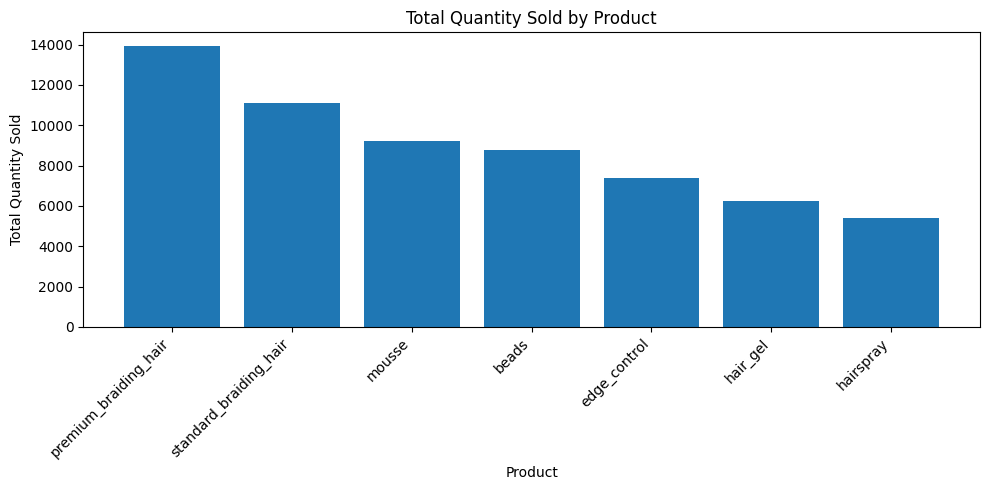

In [24]:
product_usage = df.groupby('item_name')['quantity_sold'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(product_usage.index, product_usage.values)
plt.title('Total Quantity Sold by Product')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


This graph compares average product usage between weekdays and weekends, showing how demand changes over time.

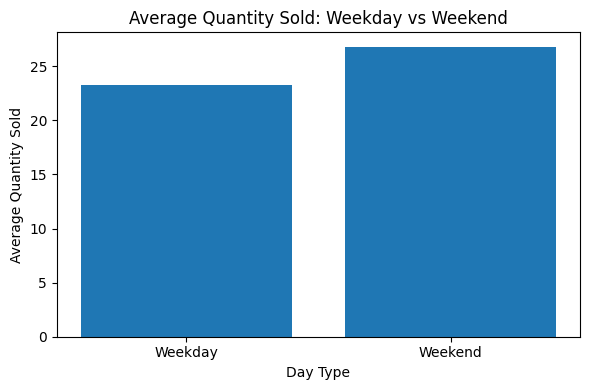

In [25]:
weekend_usage = df.groupby('is_weekend')['quantity_sold'].mean()

plt.figure(figsize=(6, 4))
plt.bar(['Weekday', 'Weekend'], weekend_usage.values)
plt.title('Average Quantity Sold: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Average Quantity Sold')
plt.tight_layout()
plt.show()



This pivot table below shows the average amount of each product used for different hairstyles, helping identify how product demand varies depending on the service.

In [26]:
style_item_usage = df.pivot_table(
    index='style_type',
    columns='item_name',
    values='quantity_sold',
    aggfunc='mean'
)

style_item_usage


item_name,beads,edge_control,hair_gel,hairspray,mousse,premium_braiding_hair,standard_braiding_hair
style_type,,,,,,,
box_braids,24.109756,19.480769,16.050633,15.520833,25.635294,41.868687,31.521277
cornrows,24.961538,23.591549,19.080808,12.988764,22.736842,31.500000,30.149425
knotless,24.231481,19.741176,15.977528,16.368421,27.580000,44.666667,27.879121
twists,23.185567,19.114286,16.806122,13.905882,24.823529,33.435294,32.086022


This heatmap visualizes the average product usage for each hairstyle, where darker colors indicate higher usage. It helps highlight how product demand varies depending on the style being performed.This essentially placed the data above into a different format. 

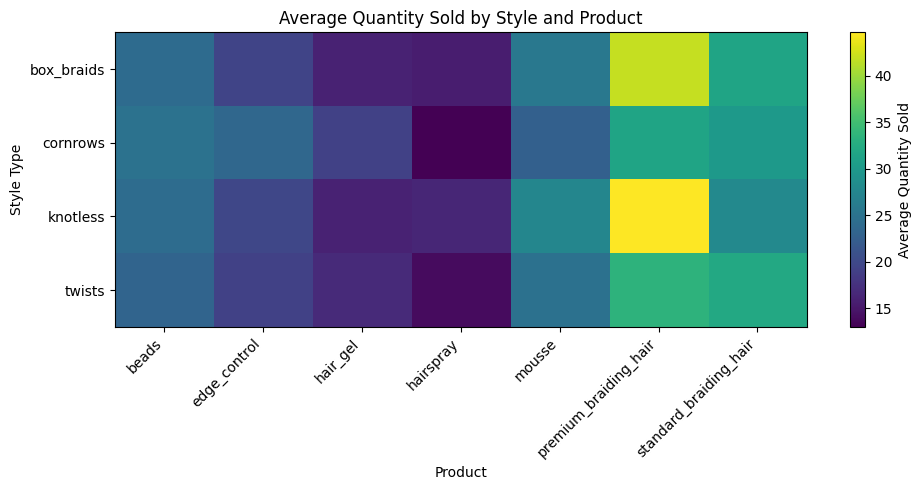

In [27]:
plt.figure(figsize=(10, 5))
plt.imshow(style_item_usage, aspect='auto')
plt.colorbar(label='Average Quantity Sold')
plt.title('Average Quantity Sold by Style and Product')
plt.xlabel('Product')
plt.ylabel('Style Type')
plt.xticks(range(len(style_item_usage.columns)), style_item_usage.columns, rotation=45, ha='right')
plt.yticks(range(len(style_item_usage.index)), style_item_usage.index)
plt.tight_layout()
plt.show()

# Outlier Data
I wanted to also check my data for any outliers to make sure my dataset remains realistic and doesn’t contain extreme or incorrect values. I used the IQR method to determine a range for each product in inventgory so anything falling outside of that range was considered an outlier.

In [43]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np

def find_outliers_iqr(dataframe, column):
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = dataframe[(dataframe[column] < lower) | (dataframe[column] > upper)]
    return lower, upper, outliers

for col in ['price', 'stock_level', 'quantity_sold', 'appointments_per_day', 'lag_sales', 'rolling_avg_3', 'stock_pressure']:
    lower, upper, outliers = find_outliers_iqr(df, col)
    print(f'{col}: {len(outliers)} outliers | lower={lower:.2f}, upper={upper:.2f}')


price: 0 outliers | lower=-5.81, upper=26.37
stock_level: 0 outliers | lower=-18.50, upper=113.50
quantity_sold: 86 outliers | lower=-1.00, upper=47.00
appointments_per_day: 2 outliers | lower=2.00, upper=18.00
lag_sales: 86 outliers | lower=-1.00, upper=47.00
rolling_avg_3: 60 outliers | lower=1.50, upper=45.50
stock_pressure: 80 outliers | lower=-2.21, upper=11.32


In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,  stratify=y
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))


Training size: 2044
Testing size: 511


In [14]:
print(X_train.shape)
print(y_train.shape)

(2044, 13)
(2044,)


In [8]:
y_pred = model.predict(X_test)

print("Model Evaluation:\n")
print(classification_report(y_test, y_pred))

Model Evaluation:

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       409
           1       0.82      0.95      0.88       102

    accuracy                           0.95       511
   macro avg       0.90      0.95      0.92       511
weighted avg       0.95      0.95      0.95       511



This graph shows below the importance of each feature in predicting stockouts, highlighting which factors have the most influence on the model’s decisions.

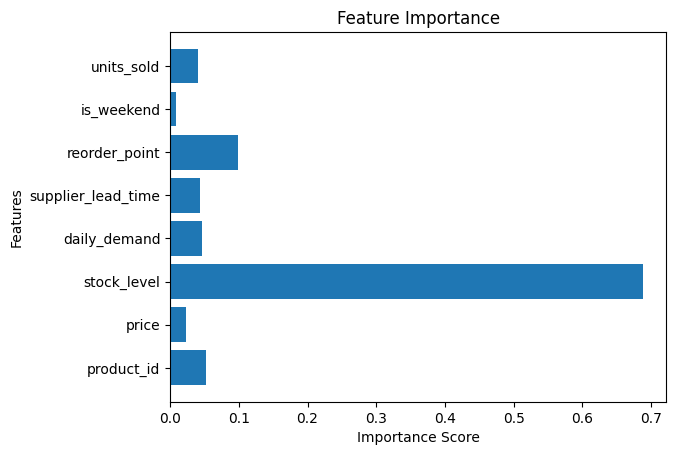

In [14]:
import matplotlib.pyplot as plt

feature_importances = model.feature_importances_
features = X.columns

plt.barh(features, feature_importances)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [13]:
import os
import joblib
os.makedirs("../models", exist_ok=True)

joblib.dump(model, "inventory_model.pkl")
joblib.dump(encoder, "encoder.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved!")

Model saved!


In [10]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Classification Report:')
print(classification_report(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.949119373776908
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       409
           1       0.82      0.95      0.88       102

    accuracy                           0.95       511
   macro avg       0.90      0.95      0.92       511
weighted avg       0.95      0.95      0.95       511

Confusion Matrix:
[[388  21]
 [  5  97]]


The model is about 95% accurate and does a great job catching stockouts, correctly identifying most cases where inventory runs out, with very few missed.